<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [6]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=14820f9b-7d1b-40a4-87a6-00b4f8c4d8d7
To: /Users/verazinovyeva/Codding/DLS 2026 spring/DLS Speech/sound_classification_dataset.zip
100%|████████████████████████████████████████| 645M/645M [02:16<00:00, 4.72MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /Users/verazinovyeva/Codding/DLS 2026 spring/DLS Speech/train.csv
100%|██████████████████████████████████████| 3.09k/3.09k [00:00<00:00, 4.84MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /Users/verazinovyeva/Codding/DLS 2026 spring/DLS Speech/valid.csv
100%|██████████████████████████████████████| 1.06k/1.06k [00:00<00:00, 2.94MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /Users/verazinovyeva/Codding/

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [ ]:
!unzip sound_classification_dataset.zip

In [1]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [3]:
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os
import torchaudio.transforms as T
import torch.nn.functional as F

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, audio_file_path, label=None, classes = None, do_augmentation=False, new_freq = 16000, X = 3):
        """ Сохраним то, что нам нужно будет в классе """
        self.audio_file_path = audio_file_path # путь к файлам
        self.label = label # к какому классу относится (dog, rain и тд) 
        self.classes = classes # список всех классов ()создали его, потмоу что он будет использоваться в
        # class ESC50TestDemo. Нужен нам, чтобы переводить слово в число для модели
        self.do_augmentation = do_augmentation # что-то меняем в аудио на train, чтобы модлеь лучше училась
        self.new_freq = new_freq # зададим 16000 Гц (чтобы все аудио были в одном формате)
        self.X = X # зададим кол-во секунд к которму приведем все аудиофайлы
        self.target_length = X * new_freq # зададим фиксир размер сэмпла


    def __len__(self):
        '''Смотрим сколько всего объектов в датасете'''
        len_Dataset = len(self.audio_file_path)
        return len_Dataset 


    def __getitem__(self, index):
        # 1. Get the file path and label
        # index — это номер файла в датасете
        audio_file_path = self.audio_file_path[index] # возьмем файл с индексом index

        # 2. LOAD: Load the raw audio file
        # загрузим signal, то есть сам звук (тензор с числами)
        # загрузим sample_rate (сколько значений в секунду)
        signal, sample_rate = torchaudio.load(audio_file_path) 
        
        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation: # если для датасета включена аугментация, то меням что-то
            signal = self._augmentation(signal)

        signal = signal.squeeze(1)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        if self.label is not None: # проверяем есть ли у файла метки 
            label = self.label[index] # если не None, то берем index текущ эл
            return signal, label
        else:
            return signal

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        """ Приводим аудио к одинаковой частоте 16000 Hz"""
        # Resample from original sample_rate to 16000 Hz
        resampler = T.Resample(orig_freq=original_sr, new_freq=self.new_freq)
        signal = resampler(signal)

        return signal

    def _stereo_to_mono(self, signal):
        """ Приводим многоканальное аудио в моноканальное"""
       # signal, sample_rate = torchaudio.load(audio_file_path)  # Replace with your file
        # Convert to mono if stereo
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)

        return signal

    def _cut_or_pad(self, signal):
        '''Сделаем всем одинаковую длину:
        если аудио слишком длинное, обрежем
        если аудио слишком короткое, допишем нули
        '''
        current_length = signal.shape[1]
        
        if current_length > self.target_length:
            signal = signal[:, :self.target_length]
        elif current_length < self.target_length:
            pad_amount = self.target_length - current_length
            signal = F.pad(signal, (0, pad_amount))

        return signal

    def _augmentation(self, signal):
        """Mеняем в аудио на train, чтобы модлеь лучше училась"""
        # Случайное изменение громкости
        if torch.rand(1).item() < 0.5: # с вероятностью 50% меняем громкость
            gain = torch.empty(1).uniform_(0.8, 1.2).item() # берем случайный коэффициент громкости от 0.8 до 1.2.
            signal = signal * gain # меняем амплитуду, то есть громкость

        # Добавление небольшого шума
        if torch.rand(1).item() < 0.5:  # с вероятностью 50% меняем 
            noise_level = torch.empty(1).uniform_(0.001, 0.01).item() # создаем случайное число от 0.001 до 0.01
            noise = torch.randn_like(signal) * noise_level # создаем случайный шум 
            signal = signal + noise # добавляем шум

        # Случайный сдвиг по времени
        if torch.rand(1).item() < 0.5:
            max_shift = int(0.1 * signal.shape[-1]) # максимум сдвига 10% длины сигнала
            shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()
            signal = torch.roll(signal, shifts=shift, dims=1) # dims=1 — время, сдвигаем сигнал по оси времени

        signal = torch.clamp(signal, -1.0, 1.0) # если после преобразований значени яслишком большие или маленькие, приведем от -1 до 1

        return signal

In [4]:
audio_dir = "./content/sound_classification_dataset" # наш путь

# переводим категории в числа
labels_sorted = sorted(train_df["category"].unique()) # сортируем классы, чтобы потом перевести слова в цифры для модели
label2id = {label: i for i, label in enumerate(labels_sorted)} # создаем словарь, где словам присваиваются цифры
id2label = {i: label for label, i in label2id.items()} # обратно меняем цифру на метку, нужно для submission

train_df["label_id"] = train_df["category"].map(label2id) # заменяем каждую метку (слово) на число
valid_df["label_id"] = valid_df["category"].map(label2id)
classes = labels_sorted # сохраняем список классов в переменную classes

train_dataset = SimpleAudioDataset(
    audio_file_path=[os.path.join(audio_dir, x) for x in train_df["filename"].tolist()],
    label=train_df["label_id"].tolist(),
    classes=classes,
    do_augmentation=True
)

valid_dataset = SimpleAudioDataset(
    audio_file_path=[os.path.join(audio_dir, x) for x in valid_df["filename"].tolist()],
    label=valid_df["label_id"].tolist(),
    classes=classes,
    do_augmentation=False)

test_dataset = SimpleAudioDataset(
    audio_file_path=[os.path.join(audio_dir, x) for x in test_df["filename"].tolist()],
    classes=classes,
    do_augmentation=False
)



### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [5]:
import torch.nn as nn

class SoundClassificationModel(nn.Module):
    def __init__(self, num_classes=5): # создаем модлеь для 5 классов
        super().__init__()
        # кол-во фильтов 
        base = 32
        c1 = base
        c2 = base * 2
        c3 = base * 4   
        
        # делаем 1 входной канал и 16 выходных, stride - это шаг с которым идем, padding - заполяем края
        self.conv1 = nn.Conv1d(1, c1, kernel_size=9, stride=2, padding=4) 
        self.bn1 = nn.BatchNorm1d(c1) # нормализуем каналы, если они получились слишком разного масштаба
        self.relu1 = nn.ReLU() # функция активации
        self.pool1 = nn.MaxPool1d(4) # смотрим на 4 элемента и берем из них максим (то есть делаем пулинг)


        self.conv2 = nn.Conv1d(c1, c2, kernel_size=7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(c2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(c2, c3, kernel_size=5, stride=2, padding=2)
        self.bn3 = nn.BatchNorm1d(c3)
        self.relu3 = nn.ReLU()

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(c3, num_classes)

    def forward(self, x):
        
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.relu3(self.bn3(self.conv3(x)))

        x = self.global_pool(x) # усредняем признаки по времени
        x = x.squeeze(-1) # убираем размерность длины 1 (после пулинга)
        x = self.dropout(x) # Dropout случайно зануляет часть признаков во время обучения (чтобы не было переобучения)
        x = self.fc(x) # превращаеv 64 признака в 5 выходов
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [6]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


In [7]:
from torch.utils.data import DataLoader
from IPython.display import clear_output
import copy

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificationModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # добавим weight_decay=1e-4
# чтобы уменьшить переобучение

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

best_valid_acc = 0.0
best_state = None

n_epochs = 30 # кол-во эпох возьмем 30
for epoch in range(n_epochs):
    model.train()

    train_loss_sum = 0.0 # суммарный loss по всем объектам обучающей выборки за эпоху
    train_correct = 0 # счетчик - сколько объектов в батче модель угадала правильно
    train_total = 0 # cчетчик - общее числа объектов за эпоху

    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad() # обнуляем градиенты перед новым шагом обучения
        outputs = model(signals) # подаем сигналы в модель и получаем выходы
        loss = criterion(outputs, labels) # cчитаем ошибку модели
        loss.backward() # обратное распространение ошибки
        optimizer.step() # обновляем параметры модели с помощью оптимизатора

        preds = outputs.argmax(dim=1) # предсказанные классы, dim=1 - чтобы выбрать наиболлее вер класс

        train_loss_sum += loss.item() * labels.size(0)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total

    model.eval()
    
    valid_loss_sum = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            valid_loss_sum += loss.item() * labels.size(0)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    epoch_valid_loss = valid_loss_sum / valid_total
    epoch_valid_acc = valid_correct / valid_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    if epoch_valid_acc > best_valid_acc:
        best_valid_acc = epoch_valid_acc
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
    print(f"Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}")

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

model.load_state_dict(best_state)


<All keys matched successfully>

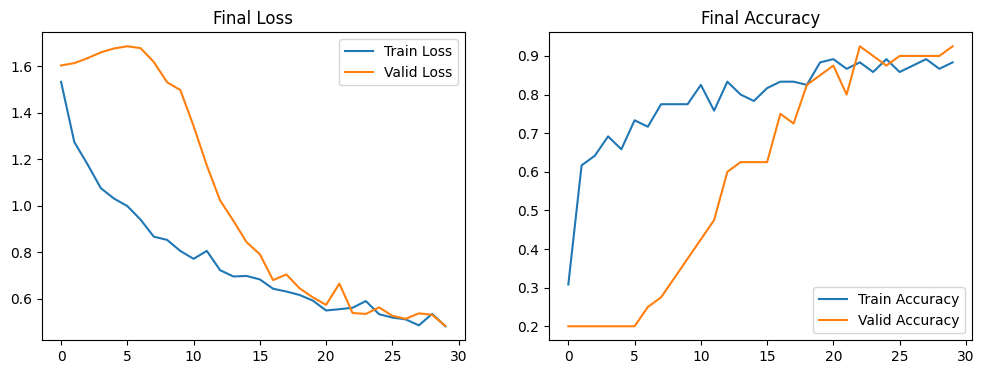

In [10]:
model.load_state_dict(best_state)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.legend()
plt.title("Final Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(valid_accuracies, label="Valid Accuracy")
plt.legend()
plt.title("Final Accuracy")

plt.show()

In [12]:
print("Train Accuracy = ", epoch_train_acc)
print("Valid Accuracy = ", epoch_valid_acc)

Train Accuracy =  0.8833333333333333
Valid Accuracy =  0.925


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cpu
ESC-50 Audio Classification Demo!


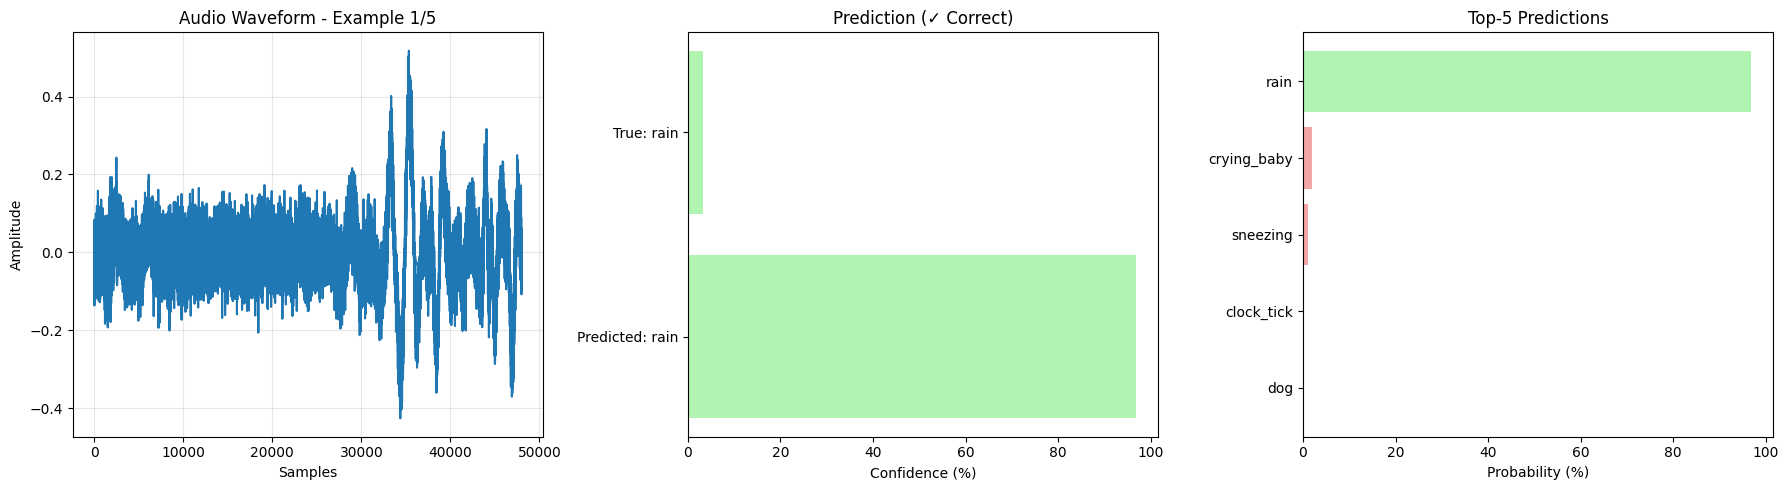

Playing: rain


Prediction: rain (96.73%)
True label: rain
Correct: True


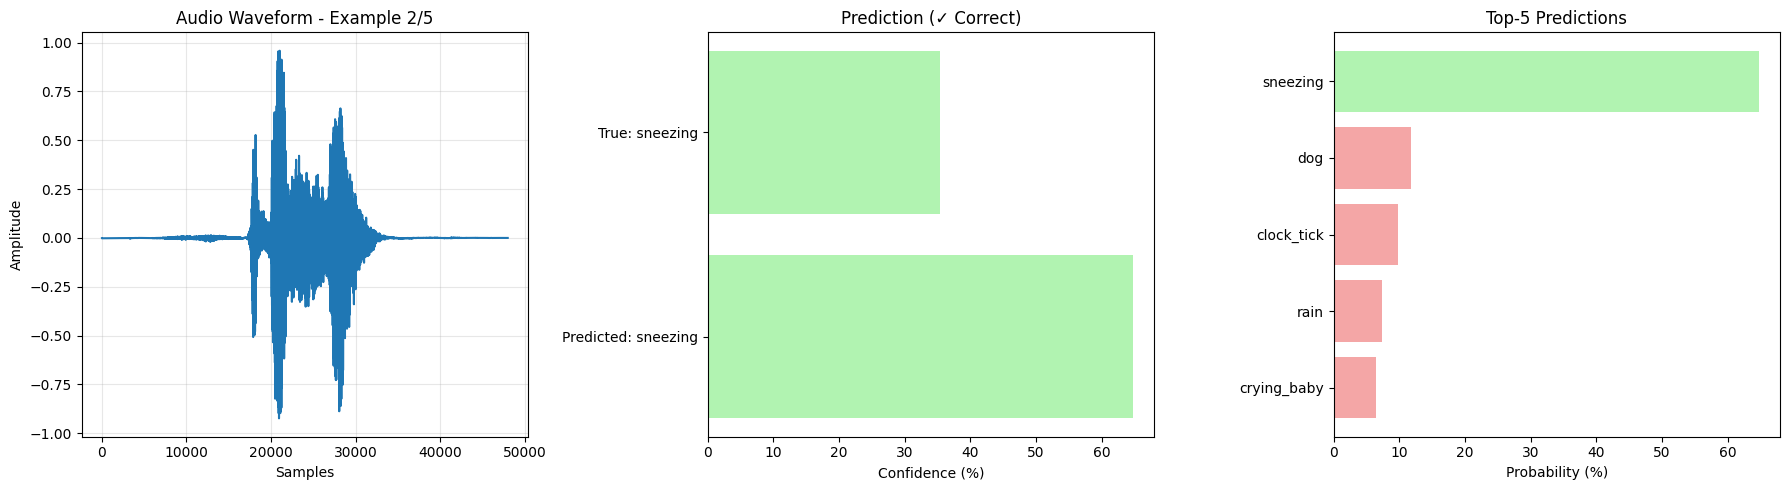

Playing: sneezing


Prediction: sneezing (64.70%)
True label: sneezing
Correct: True


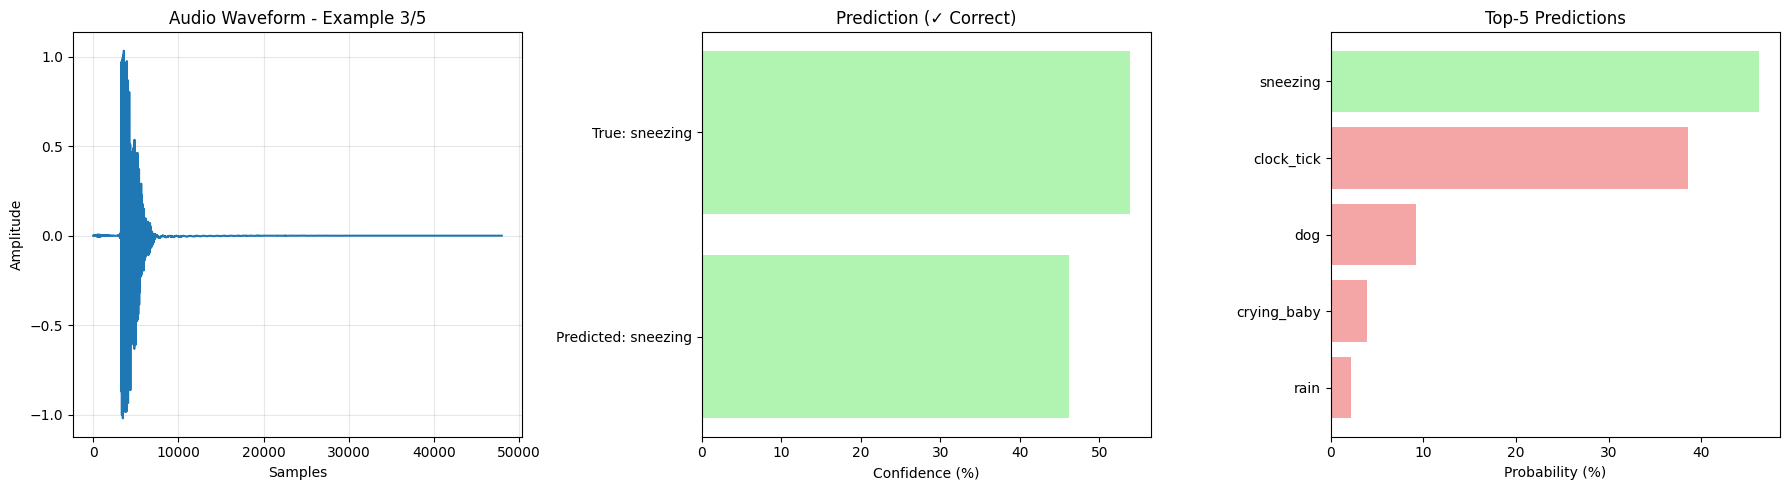

Playing: sneezing


Prediction: sneezing (46.17%)
True label: sneezing
Correct: True


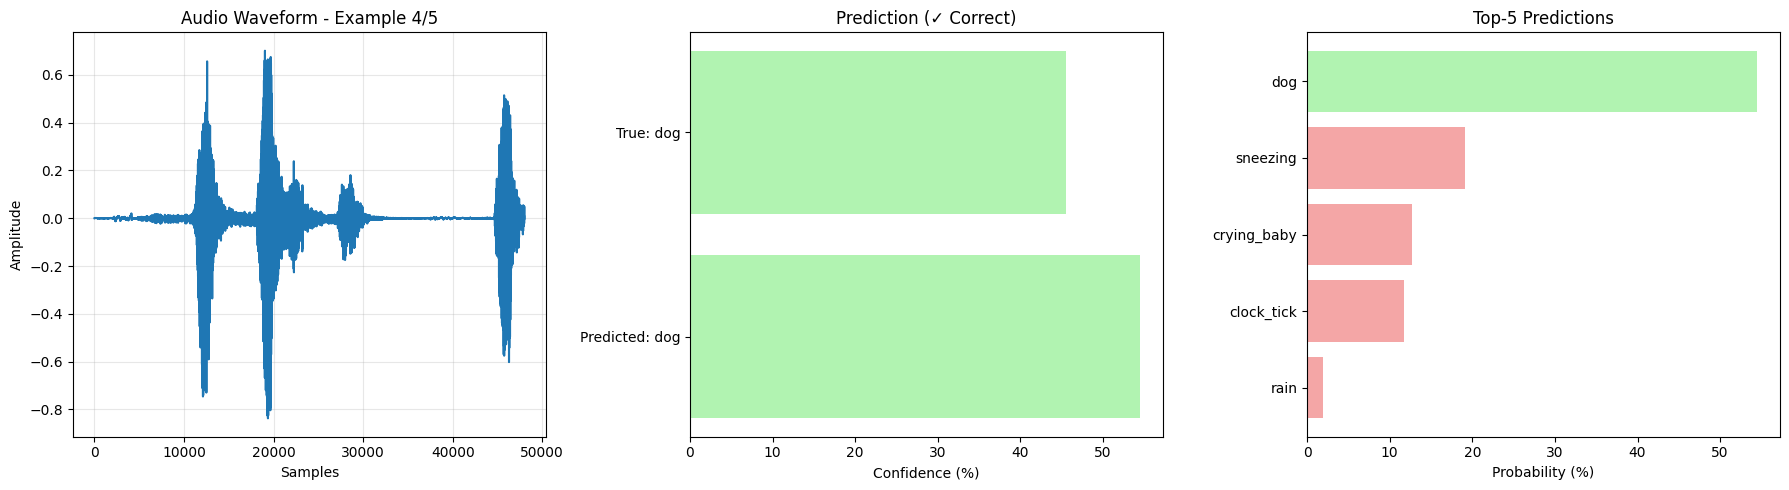

Playing: dog


Prediction: dog (54.52%)
True label: dog
Correct: True


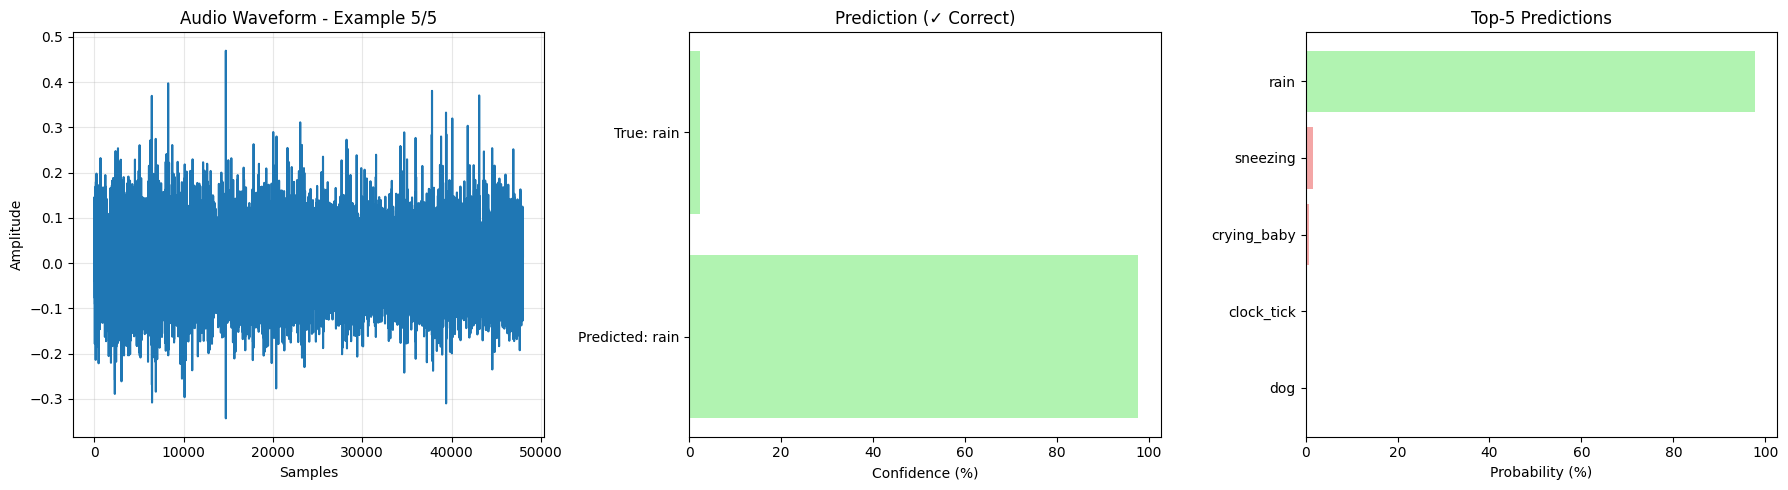

Playing: rain


Prediction: rain (97.70%)
True label: rain
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 37/40
Accuracy: 92.50%


In [13]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [14]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.load_state_dict(best_state)
model.to(device)
model.eval()

predictions_test = []

with torch.no_grad():
    for signals in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        preds = outputs.argmax(dim=1)
        predictions_test.extend(preds.cpu().numpy())


In [15]:
y_test_pred = [id2label[int(i)] for i in predictions_test]

In [16]:
submission = pd.read_csv("test.csv")
submission['category'] = y_test_pred
submission.to_csv("submission.csv", index=False)

### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.